In [1]:
import numpy as np
import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import *

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

from tqdm.auto import tqdm

In [2]:
FEATURE_PATH="/kaggle/input/datasets/varshavp13/multimodal-features"

video_features=np.load(FEATURE_PATH+"/video_features.npy")

audio_features=np.load(FEATURE_PATH+"/audio_features.npy")

labels=np.load(FEATURE_PATH+"/labels.npy")

In [3]:
X_video_train, X_video_test,\
X_audio_train, X_audio_test,\
y_train,y_test=train_test_split(

video_features,
audio_features,
labels,

test_size=0.20,

random_state=42,

stratify=labels

)

X_video_train,X_video_val,\
X_audio_train,X_audio_val,\
y_train,y_val=train_test_split(

X_video_train,
X_audio_train,
y_train,

test_size=0.20,

random_state=42,

stratify=y_train

)

In [5]:
import torch
from torch.utils.data import Dataset

class MultimodalDataset(Dataset):

    def __init__(self, video, audio, labels):

        self.video = torch.FloatTensor(video)
        self.audio = torch.FloatTensor(audio)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        return (
            self.video[idx],
            self.audio[idx],
            self.labels[idx]
        )

In [8]:
from torch.utils.data import DataLoader

train_dataset = MultimodalDataset(
    X_video_train,
    X_audio_train,
    y_train
)

val_dataset = MultimodalDataset(
    X_video_val,
    X_audio_val,
    y_val
)

test_dataset = MultimodalDataset(
    X_video_test,
    X_audio_test,
    y_test
)

train_loader = DataLoader(train_dataset,
                          batch_size=32,
                          shuffle=True)

val_loader = DataLoader(val_dataset,
                        batch_size=32,
                        shuffle=False)

test_loader = DataLoader(test_dataset,
                         batch_size=32,
                         shuffle=False)

print(len(train_loader),
      len(val_loader),
      len(test_loader))

20 5 7


In [10]:
import torch.nn as nn
import torch

class LateFusionNet(nn.Module):

    def __init__(self):

        super().__init__()

        # Video Branch
        self.video_branch = nn.Sequential(

            nn.Linear(768,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256,64),
            nn.ReLU(),

            nn.Linear(64,2)
        )

        # Audio Branch
        self.audio_branch = nn.Sequential(

            nn.Linear(768,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256,64),
            nn.ReLU(),

            nn.Linear(64,2)
        )

    def forward(self, video, audio):

        video_logits = self.video_branch(video)

        audio_logits = self.audio_branch(audio)

        video_prob = torch.softmax(video_logits, dim=1)

        audio_prob = torch.softmax(audio_logits, dim=1)

        fused_prob = (video_prob + audio_prob) / 2

        return fused_prob

In [11]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = LateFusionNet().to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print(model)

LateFusionNet(
  (video_branch): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
  (audio_branch): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [13]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for video, audio, label in loader:

        video = video.to(DEVICE)
        audio = audio.to(DEVICE)
        label = label.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(video, audio)

        loss = criterion(outputs, label)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        pred = outputs.argmax(1)

        correct += (pred == label).sum().item()

        total += label.size(0)

    return running_loss / len(loader), 100 * correct / total

In [14]:
def evaluate(model, loader):

    model.eval()

    total_loss = 0

    correct = 0

    total = 0

    preds = []

    actual = []

    probabilities = []

    with torch.no_grad():

        for video, audio, label in loader:

            video = video.to(DEVICE)
            audio = audio.to(DEVICE)
            label = label.to(DEVICE)

            outputs = model(video, audio)

            loss = criterion(outputs, label)

            total_loss += loss.item()

            pred = outputs.argmax(1)

            preds.extend(pred.cpu().numpy())

            actual.extend(label.cpu().numpy())

            probabilities.extend(outputs[:,1].cpu().numpy())

            correct += (pred == label).sum().item()

            total += label.size(0)

    return (
        total_loss/len(loader),
        100*correct/total,
        preds,
        actual,
        probabilities
    )

In [15]:
train_acc_history = []
val_acc_history = []

train_loss_history = []
val_loss_history = []

best_acc = 0

EPOCHS = 20

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc, _, _, _ = evaluate(
        model,
        val_loader
    )

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
        f" | Train Acc {train_acc:.2f}"
        f" | Val Acc {val_acc:.2f}"
    )

    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_late_fusion.pth"
        )

Epoch 1/20 | Train Acc 62.81 | Val Acc 66.88
Epoch 2/20 | Train Acc 76.41 | Val Acc 73.75
Epoch 3/20 | Train Acc 78.59 | Val Acc 74.38
Epoch 4/20 | Train Acc 81.09 | Val Acc 75.62
Epoch 5/20 | Train Acc 83.59 | Val Acc 76.88
Epoch 6/20 | Train Acc 83.44 | Val Acc 78.12
Epoch 7/20 | Train Acc 86.09 | Val Acc 77.50
Epoch 8/20 | Train Acc 88.44 | Val Acc 79.38
Epoch 9/20 | Train Acc 88.59 | Val Acc 81.25
Epoch 10/20 | Train Acc 90.47 | Val Acc 82.50
Epoch 11/20 | Train Acc 89.69 | Val Acc 82.50
Epoch 12/20 | Train Acc 91.72 | Val Acc 85.00
Epoch 13/20 | Train Acc 92.50 | Val Acc 85.62
Epoch 14/20 | Train Acc 93.12 | Val Acc 85.00
Epoch 15/20 | Train Acc 93.59 | Val Acc 85.62
Epoch 16/20 | Train Acc 94.53 | Val Acc 86.25
Epoch 17/20 | Train Acc 94.84 | Val Acc 86.25
Epoch 18/20 | Train Acc 95.47 | Val Acc 86.25
Epoch 19/20 | Train Acc 95.62 | Val Acc 85.62
Epoch 20/20 | Train Acc 95.78 | Val Acc 88.75


In [16]:
model.load_state_dict(torch.load("best_late_fusion.pth"))

test_loss, test_acc, preds, actual, probabilities = evaluate(
    model,
    test_loader
)

print(f"\nTest Accuracy : {test_acc:.2f}%")


Test Accuracy : 86.50%


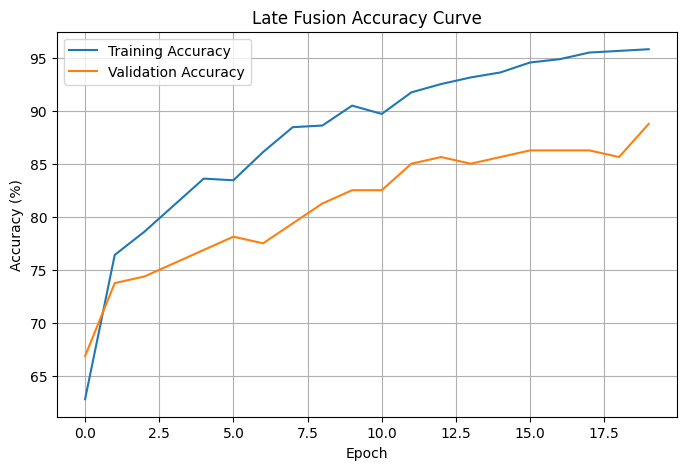

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_acc_history,label="Training Accuracy")
plt.plot(val_acc_history,label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Late Fusion Accuracy Curve")

plt.legend()

plt.grid()

plt.show()

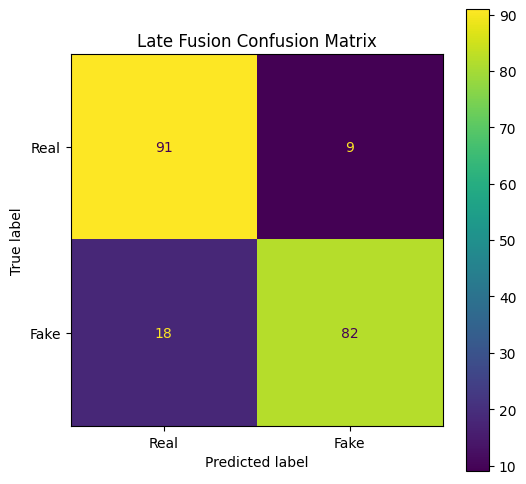

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(actual,preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Real","Fake"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(ax=ax)

plt.title("Late Fusion Confusion Matrix")

plt.show()

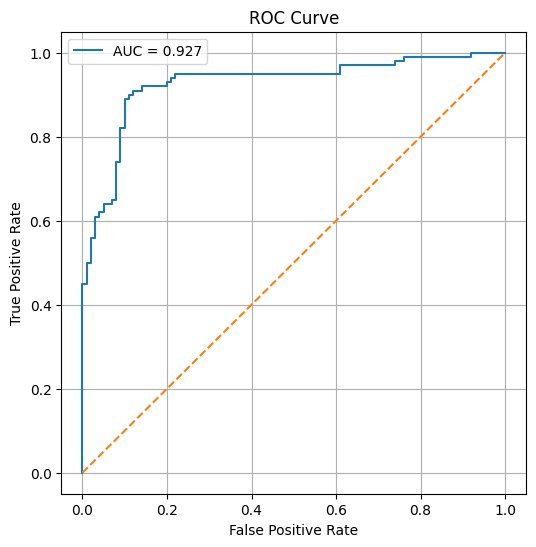

In [21]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

model.eval()

probabilities = []

with torch.no_grad():

    for video,audio,label in test_loader:

        video = video.to(DEVICE)

        audio = audio.to(DEVICE)

        outputs = model(video,audio)

        prob = torch.softmax(outputs,dim=1)[:,1]

        probabilities.extend(prob.cpu().numpy())

fpr,tpr,_ = roc_curve(actual,probabilities)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr,tpr,label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()

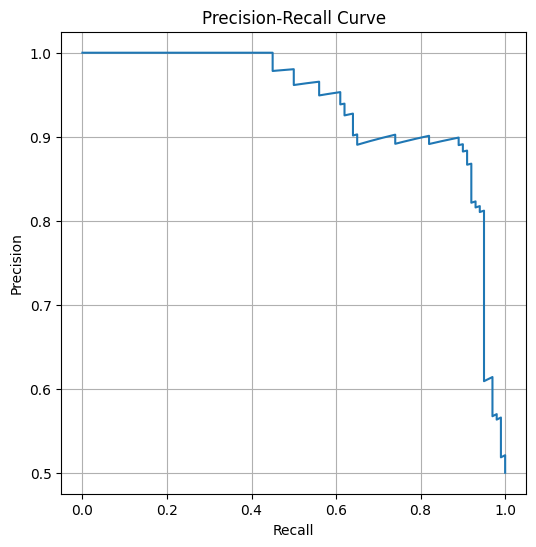

In [22]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    actual,
    probabilities
)

plt.figure(figsize=(6,6))

plt.plot(recall,precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid()

plt.show()

In [23]:
import pandas as pd

results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        test_acc,
        precision_score(actual,preds),
        recall_score(actual,preds),
        f1_score(actual,preds)
    ]

})

print(results)

      Metric      Value
0   Accuracy  86.500000
1  Precision   0.901099
2     Recall   0.820000
3   F1 Score   0.858639
